In [1]:
import numpy as np
import pandas as pd
from scipy.stats import trim_mean
import matplotlib.pyplot as plt

# 데이터: 키 (단위 cm)
# 예시 데이터: 1,000명의 키 데이터 + 일부 이상치
np.random.seed(42)
normal_data = np.random.normal(loc=170, scale=10, size=1000)  # 평균 170, 표준편차 10인 정규분포

# 각 데이터 항목에 대해 외부의 변수를 가중치로 설정한다고 가정 (데이터 길이에 맞는 임의 값)
# 해당 예시에서의 가중치는 각 데이터에 대한 중요도를 의미
weights = np.random.randint(1, 10, size=len(normal_data))  # 1에서 10 사이의 임의의 가중치

# DataFrame으로 변환
df = pd.DataFrame(normal_data, columns=['Height'])

df


,Height
0,174.967142
1,168.617357
2,176.476885
3,185.230299
4,167.658466
...,...
995,167.188997
996,187.976865
997,176.408429
998,164.288210


In [2]:
# 기초 통계량 계산
mean_value = df['Height'].mean()  # TODO: 평균 계산
median_value = df['Height'].median()  # TODO: 중앙값 계산
std_dev = df['Height'].std()  # TODO: 표준편차 계산
Q1 = df['Height'].quantile(0.25)  # TODO: 첫 번째 사분위수 계산
Q3 = df['Height'].quantile(0.75)  # TODO: 세 번째 사분위수 계산
IQR = Q3-Q1  # TODO: IQR 계산

In [4]:
# 이상치 경계 계산 (1.5보다 느슨한 검사를 위해 2로 설정)
lower_bound = Q1 - 2*IQR
upper_bound = Q3 + 2*IQR

# 이상치 확인
outliers = df[(df['Height'] < lower_bound) | (df['Height'] > upper_bound)]

print(f'평균: {mean_value}, 중앙값: {median_value}, 표준편차: {std_dev}')
print(f'Q1: {Q1}, Q3: {Q3}, IQR: {IQR}')
print(f'이상치: {outliers}')

평균: 170.19332055822326, 중앙값: 170.2530061223489, 표준편차: 9.792159381796756
Q1: 163.52409694537647, Q3: 176.4794387547293, IQR: 12.95534180935283
이상치:          Height
209  208.527315
262  137.587327


In [7]:
# 가중평균 계산 (가중치로 설정)
weighted_mean = np.average(df['Height'], weights=weights) # TODO: 가중평균을 계산하기 위한 코드 작성

# 절사평균 계산 (20% 절사 - 20% 절사는 데이터의 상위 10%와 하위 10%를 제외하고 나머지 데이터의 평균을 계산하는 방식)
trimmed_mean_value = trim_mean(df['Height'], 0.2) # TODO: 절사평균을 계산하기 위한 코드 작성

# 결과 출력
print(f'가중평균: {weighted_mean}')
print(f'절사평균 (20% 절사): {trimmed_mean_value}')

가중평균: 169.8999257215458
절사평균 (20% 절사): 170.04621346015674


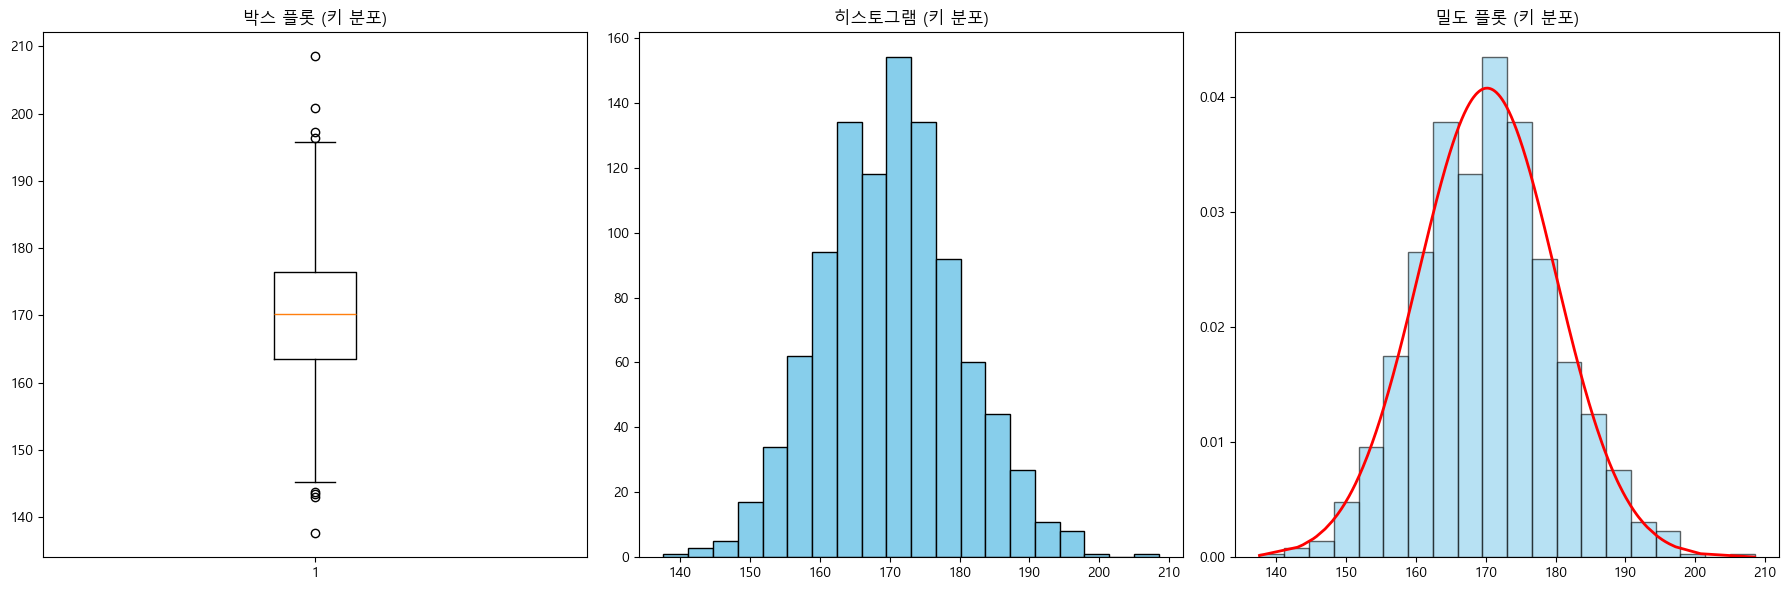

In [8]:
# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 시각화
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# 박스 플롯: 중앙값, 사분위수, 이상치 확인
ax[0].boxplot(df['Height'])
ax[0].set_title('박스 플롯 (키 분포)')

# 히스토그램: 데이터의 분포와 퍼짐 확인
ax[1].hist(df['Height'], bins=20, color='skyblue', edgecolor='black')
ax[1].set_title('히스토그램 (키 분포)')

# 밀도 플롯: 데이터의 분포를 부드럽게 나타내는 밀도 곡선
ax[2].hist(df['Height'], bins=20, density=True, alpha=0.6, color='skyblue', edgecolor='black')
ax[2].plot(np.sort(df['Height']), 
           1/(std_dev * np.sqrt(2 * np.pi)) * np.exp(- (np.sort(df['Height']) - mean_value)**2 / (2 * std_dev**2)),
           color='red', linewidth=2)
ax[2].set_title('밀도 플롯 (키 분포)')

plt.tight_layout()
plt.show()
